<h1><font color="#113D68" size=6>Deep Learning en Python con PyTorch</font></h1>

<h1><font color="#113D68" size=5>Parte 3. Multilayer Perceptron</font></h1>

<h1><font color="#113D68" size=4>8. Proyecto de regresión</font></h1>

<br><br>
<div style="text-align: right">
<font color="#113D68" size=3>Manuel Castillo Cara</font><br>

</div>

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
More information about [Manuel Castillo-Cara](https://www.manuelcastillo.eu/)

<div class="alert alert-block alert-info">

<i class="fa fa-info-circle" aria-hidden="true"></i>
Puedes ver más cursos de Inteligencia Artificial, Machine Learning y Deep Learning en mi [página web](https://www.manuelcastillo.eu/udemy/)


---

<a id="indice"></a>
<h2><font color="#004D7F" size=5>Índice</font></h2>

* [0. Contexto](#section0)
* [1. Descripción del Conjunto de Datos](#section1)
* [2. Construir un Modelo y Entrenarlo](#section2)
* [3. Mejorando el Modelo con Preprocesamiento](#section3)

---
<a id="section0"></a>
# <font color="#004D7F" size=6> 0. Contexto</font>

Los problemas de regresión suelen ser más fáciles de resolver en comparación con los problemas de clasificación. Muchos modelos pueden manejar bien los problemas de regresión, y el aprendizaje profundo es uno de ellos. En este capítulo, descubrirás cómo usar PyTorch para desarrollar y evaluar modelos de redes neuronales para problemas de regresión.

Después de completar este capítulo, sabrás:

- Cómo cargar datos desde scikit-learn y adaptarlos para los modelos de PyTorch  
- Cómo crear una red neuronal para problemas de regresión utilizando PyTorch  
- Cómo mejorar el rendimiento del modelo con técnicas de preparación de datos 

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section1"></a>
# <font color="#004D7F" size=6>1. Descripción del Conjunto de Datos</font>

- Conjunto de datos: Viviendas de California (California housing dataset)

- Descripción: Valor medio de casas en distritos de California

- Variable objetivo: 
  - Valor medio de vivienda

  - En múltiplos de USD 100,000

  - Datos de 1990

- Características de entrada (8):
  1. MedInc: Ingreso medio en el grupo de bloques

  2. HouseAge: Edad media de las casas

  3. AveRooms: Promedio de habitaciones por hogar

  4. AveBedrms: Promedio de dormitorios por hogar

  5. Population: Población del grupo de bloques

  6. AveOccup: Promedio de miembros por hogar

  7. Latitude: Latitud del centroide del grupo

  8. Longitude: Longitud del centroide del grupo

- Particularidades del conjunto:
  - Datos de entrada en escalas muy diferentes

  - Mayoría de características positivas, excepto longitud (negativa)

  - Desafío: Manejar la diversidad de escalas en los datos

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre el dataset [Boston House Price](http://lib.stat.cmu.edu/datasets/boston)

In [1]:
# Descarga de datos (necesario en Colab): se guardan en ./Datasets
import os, urllib.request

os.makedirs('Datasets', exist_ok=True)
urls = {
    'housing.csv':
        'https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.data',
}
for nombre, url in urls.items():
    if not os.path.exists(f'Datasets/{nombre}'):
        urllib.request.urlretrieve(url, f'Datasets/{nombre}')

In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split

data = pd.read_csv("Datasets/housing.csv", sep=r'\s+', header=None)
X = data.iloc[:, 0:13]
y = data.iloc[:, 13]

X = torch.tensor(X.values, dtype=torch.float32)
y = torch.tensor(y.values, dtype=torch.float32).reshape(-1, 1)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, train_size=0.7, shuffle=True)

X_train = X_train_raw
y_train = y_train_raw
X_test = X_test_raw
y_test = y_test_raw

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section2"></a>
# <font color="#004D7F" size=6>2. Construir un Modelo y Entrenarlo</font>

- Tipo de problema: Regresión

- Diferencia con clasificación: Variable de salida numérica continua

- Activación en capa de salida para redes neuronales:
  - Lineal (sin activación)

  - Permite salida en rango de -∞ a +∞

- Métricas de pérdida para regresión:

  - Error cuadrático medio (MSE)

  - Error absoluto medio (MAE)
  
  - Error cuadrático medio de la raíz (RMSE)
  
    - Ventaja: Misma unidad que la variable de salida

- Diseño propuesto: Estructura piramidal
  - Características:
    - Número de neuronas disminuye hacia la salida
    - Primera capa oculta con gran número de neuronas
    - Reducción gradual en capas siguientes
    - Capa final produce un solo valor

In [3]:
model = nn.Sequential(
    nn.Linear(13, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)  # salida lineal: sin activación
)
model

Sequential(
  (0): Linear(in_features=13, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=6, bias=True)
  (5): ReLU()
  (6): Linear(in_features=6, out_features=1, bias=True)
)

Para entrenar esta red, necesitas definir una función de pérdida. MSE es una elección razonable. También necesitarás un optimizador, como Adam.

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`MSELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html).

In [4]:
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

- Necesidad de dividir los datos:
  - Conjunto de entrenamiento

  - Conjunto de test

- Objetivo de la división:
  - Obtener una puntuación de evaluación confiable

  - Asegurar el funcionamiento del modelo

- Prevención del sobreajuste:
  - Llevar registro del MSE en el conjunto de test

- Uso de `tqdm` en el bucle de entrenamiento:
  - Configura barra de progreso
  
  - Calcula y reporta MSE en cada iteración

  - Parámetro `disable=False` para ver cambios en MSE

- Estructura de cada época (epoch):
  1. Pasos hacia adelante y atrás con train

  2. Optimización de pesos del modelo

  3. Evaluación con test al final

- Almacenamiento de métricas:
  - MSE de test guardado en lista `history`

  - MSE de test usado para evaluar el modelo

- Guardado del mejor modelo:
  - Mejores pesos guardados en variable `best_weights`

- Resultados finales:
  - Mejor modelo restaurado

  - Mejor MSE guardado en `best_mse`

- Visualización de resultados:
  - Mostrar MSE y RMSE

  - Graficar historia del MSE (debe disminuir con las épocas)

- Ventajas de este enfoque:
  - Facilita seguimiento del progreso del modelo

  - Permite restaurar los mejores pesos basados en rendimiento en test

/tmp/ipykernel_442266/2296713307.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  bar.set_postfix(mse=float(loss))


MSE: 46.26
RMSE: 6.80


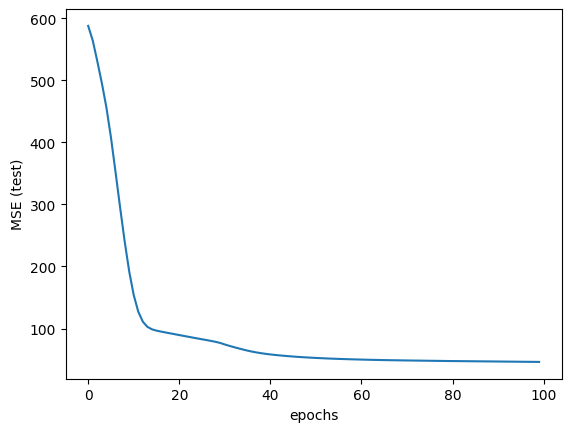

In [5]:
n_epochs = 100
batch_size = 10 
batch_start = torch.arange(0, len(X_train), batch_size)

best_mse = np.inf
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            bar.set_postfix(mse=float(loss))
    # evaluar en test al final de la época
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        mse = float(loss_fn(y_pred, y_test))
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.xlabel("epochs")
plt.ylabel("MSE (test)")
plt.show()

Cargamos ahora el mejor modelo

In [6]:
model.load_state_dict(best_weights)

<All keys matched successfully>

---
<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<a id="section3"></a>
# <font color="#004D7F" size=6>3. Mejorando el Modelo con Preprocesamiento</font>

- Problema identificado: Diversidad en las características del conjunto de datos
  - Algunas tienen rango estrecho, otras amplio

  - Algunas son pequeñas y positivas, otras muy negativas

- Impacto: Afecta negativamente el rendimiento de modelos de aprendizaje automático

- Solución propuesta: Estandarización

- Proceso de estandarización:
  - Convierte cada característica en su puntuación estándar

  - Fórmula: 
    $$
       z = \frac{x - \bar{x}}{\sigma_x}
    $$

    - $\bar{x}$: media de x

    - $\sigma_x$: desviación estándar de x

- Beneficios de la estandarización:

  - Características centradas alrededor de 0

  - Rango estrecho (70% de muestras entre -1 y +1)
  
  - Facilita la convergencia del modelo

- Herramienta: `StandardScaler` de scikit-learn

<div class="alert alert-block alert-info">
    
<i class="fa fa-info-circle" aria-hidden="true"></i>
Más información sobre [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [7]:
from sklearn.preprocessing import StandardScaler

# Read data
data = pd.read_csv("Datasets/housing.csv", sep=r'\s+', header=None)
X = data.iloc[:, 0:13]
y = data.iloc[:, 13]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X.values, y.values, train_size=0.7, shuffle=True)

# Estandarización: el escalador se ajusta SOLO con train (evita data leakage)
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

- Aplicación de `StandardScaler`:
  - Se realiza después de dividir los datos en train/test

- Proceso correcto de escalado:
  1. Ajustar el escalador solo con train
  
  2. Aplicar el escalador a ambos conjuntos: train y test

- Razón para no ajustar con todos los datos:
  - Evitar filtración de datos (data leakage)

  - No proporcionar información de test al modelo

- Características del modelo después del escalado:
  - Mismo número de características (13)

  - Mismo bucle de entrenamiento

- Beneficio esperado:

  - Mejora en el RMSE

MSE: 32.45
RMSE: 5.70


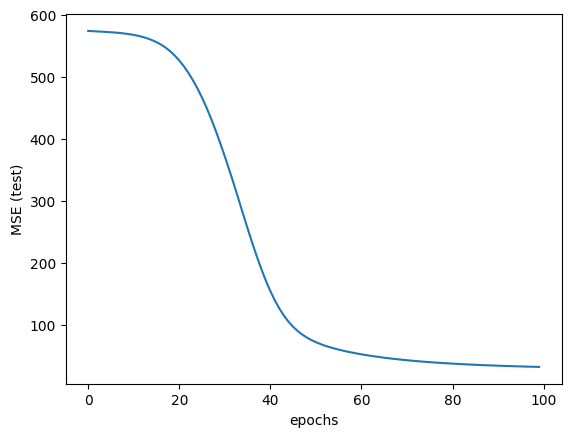

In [8]:
model = nn.Sequential(
    nn.Linear(13, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 6),
    nn.ReLU(),
    nn.Linear(6, 1)  # salida lineal: sin activación
)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 100
batch_size = 10
batch_start = torch.arange(0, len(X_train), batch_size)
best_mse = np.inf
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            bar.set_postfix(mse=float(loss))
    # evaluar en test al final de la época
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
        mse = float(loss_fn(y_pred, y_test))
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

model.load_state_dict(best_weights)
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.xlabel("epochs")
plt.ylabel("MSE (test)")
plt.show()

Aunque la historia del MSE sigue una forma descendente similar, el eje y muestra que el rendimiento es mejor después de escalar los datos.

Sin embargo, debes tener cuidado al final: cuando uses el modelo entrenado y lo apliques a nuevos datos, deberás aplicar el escalador a los datos de entrada antes de pasarlos al modelo. Es decir, la inferencia debe realizarse de la siguiente manera:

In [9]:
model.eval()
with torch.no_grad():
    for i in range(5):
        X_sample = X_test_raw[i:i+1]
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test_raw[i]} -> {y_pred[0].numpy()} (esperado {y_test[i].numpy()})")

[6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01 7.1470e+00
 5.4200e+01 6.0622e+00 3.0000e+00 2.2200e+02 1.8700e+01 3.9690e+02
 5.3300e+00] -> [34.458107] (esperado [36.2])
[  1.00245   0.        8.14      0.        0.538     6.674    87.3
   4.239     4.      307.       21.      380.23     11.98   ] -> [20.023193] (esperado [21.])
[3.4109e-01 0.0000e+00 7.3800e+00 0.0000e+00 4.9300e-01 6.4150e+00
 4.0100e+01 4.7211e+00 5.0000e+00 2.8700e+02 1.9600e+01 3.9690e+02
 6.1200e+00] -> [23.945625] (esperado [25.])
[  1.20742   0.       19.58      0.        0.605     5.875    94.6
   2.4259    5.      403.       14.7     292.29     14.43   ] -> [15.122972] (esperado [17.4])
[ 88.9762   0.      18.1      0.       0.671    6.968   91.9      1.4165
  24.     666.      20.2    396.9     17.21  ] -> [12.462814] (esperado [10.4])


Por supuesto, aún hay margen para mejorar el modelo. 

- Una forma de hacerlo es presentar la variable objetivo en escala logarítmica o, de manera equivalente, 

- Usar el error absoluto porcentual medio (MAPE) como función de pérdida. Esto se debe a que la variable objetivo es el valor de las viviendas, el cual tiene un amplio rango. 

Para un mismo error en magnitud, es más significativo en porcentaje para las viviendas de menor valor. Como ejercicio, puedes modificar el código anterior para producir una mejor predicción.

<div style="text-align: right"> <font size=5> <a href="#indice"><i class="fa fa-arrow-circle-up" aria-hidden="true" style="color:#004D7F"></i></a></font></div>

---

<div style="text-align: right"> <font size=6><i class="fa fa-coffee" aria-hidden="true" style="color:#004D7F"></i> </font></div>